In [1]:
from modules.get_data_table import get_base_data, VALUE_PIVOUT
from modules.differencing import zscore_normalize, log_difference_transform

data = get_base_data()
pivot = VALUE_PIVOUT(data)
pivot = log_difference_transform(pivot)
data.head()

,item_id,year,month,seq,type,hs4,weight,quantity,value,quantity_weight,unit_value,value_per_weight,value_per_quantity,hs4_encoded,ym,ym_seq
0,DEWLVASR,2022,1,1.0,1,3038,14858.0,0.0,32688.0,14858.0,2.200027,2.200027,0.0,2.982368,2022-01-01,2022-01-01
1,ELQGMQWE,2022,1,1.0,1,2002,62195.0,0.0,110617.0,62195.0,1.778551,1.778551,0.0,2.712733,2022-01-01,2022-01-01
2,AHMDUILJ,2022,1,1.0,1,2102,18426.0,0.0,72766.0,18426.0,3.949094,3.949094,0.0,6.462845,2022-01-01,2022-01-01
3,XIPPENFQ,2022,1,1.0,1,2501,20426.0,0.0,11172.0,20426.0,0.546950,0.546950,0.0,0.783339,2022-01-01,2022-01-01
4,FTSVTTSR,2022,1,1.0,1,2529,248000.0,0.0,143004.0,248000.0,0.576629,0.576629,0.0,0.583389,2022-01-01,2022-01-01


In [2]:
import pandas as pd

pairs = pd.read_csv('./datas/comovement_pairs.csv')
pairs

,선행품목,후행품목,선행품목hs4,후행품목hs4,최적지연기간,상관계수
0,AANGBULD,DDEXPPXU,4810,2807,11,-5.278984
1,AANGBULD,GKQIJYDH,4810,8501,12,4.159173
2,AANGBULD,GYHKIVQT,4810,8505,10,-0.895455
3,AANGBULD,HCDTGMST,4810,6006,5,-13.821071
4,AANGBULD,IGDVVKUD,4810,3824,12,15.185735
...,...,...,...,...,...,...
1304,ZXERAXWP,SUOYXCHP,4802,2805,9,-3.490219
1305,ZXERAXWP,TANNMIMB,4802,4302,11,1.609920
1306,ZXERAXWP,UXSPKBJR,4802,3206,3,-0.422030
1307,ZXERAXWP,WPQXWHYO,4802,2811,12,0.170170


In [3]:
target = 289

target_row = pairs.loc[target]
leader_key = (target_row.선행품목, target_row.선행품목hs4)
follower_key = (target_row.후행품목, target_row.후행품목hs4)       
target_row

선행품목       FDXPMYGF
후행품목       TANNMIMB
선행품목hs4        7907
후행품목hs4        4302
최적지연기간            5
상관계수      -5.259048
Name: 289, dtype: object

In [4]:
import matplotlib.pyplot as plt
 
leader = pivot.loc[[leader_key]]
follower = pivot.loc[[follower_key]]


In [5]:
# leader = leader.sub(leader.mean(axis=1), axis=0)
# follower = follower.sub(follower.mean(axis=1), axis=0)

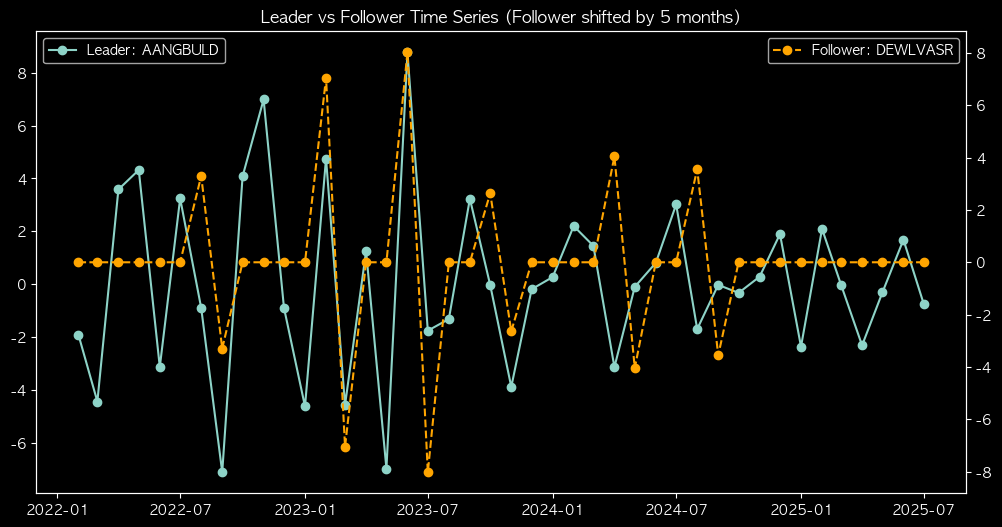

In [6]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(leader.columns, leader.values.flatten(), label='Leader: AANGBULD', marker='o')
ax2.plot(leader.columns, follower.values.flatten(), label='Follower: DEWLVASR', marker='o', linestyle='--', color='orange')
plt.title(f'Leader vs Follower Time Series (Follower shifted by {target_row.최적지연기간} months)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')


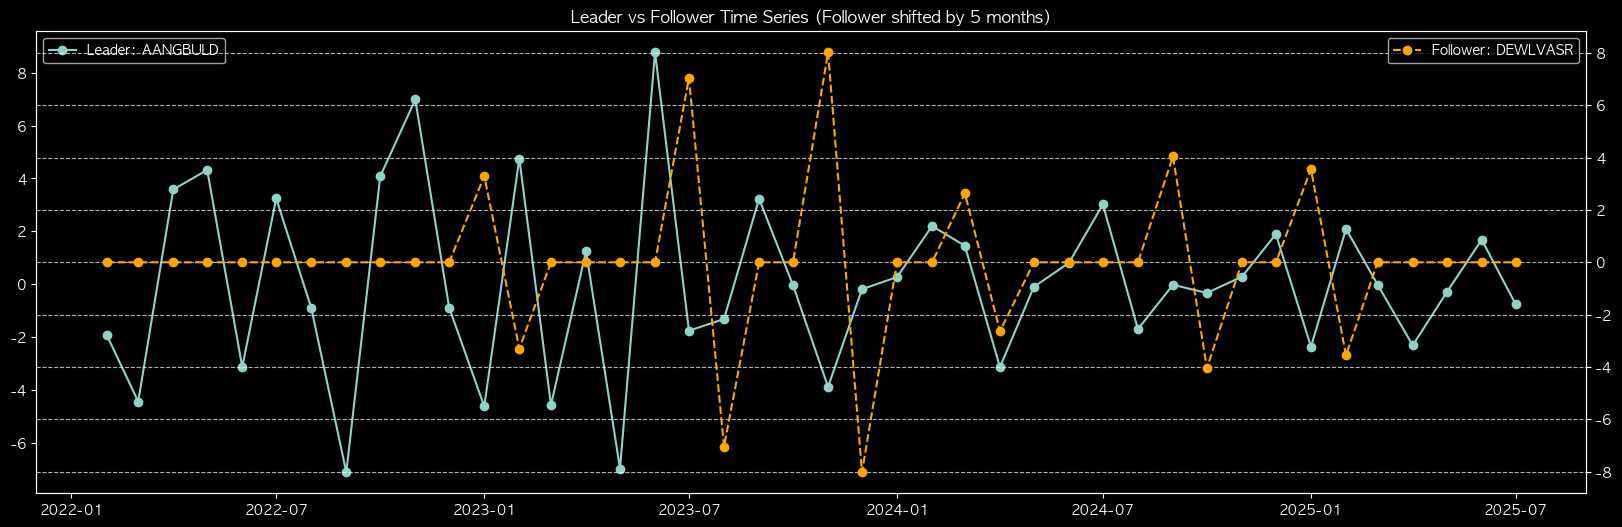

In [7]:

follower = follower.shift((target_row.최적지연기간), axis=1).fillna(0)
plt.figure(figsize=(20, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(leader.columns, leader.values.flatten(), label='Leader: AANGBULD', marker='o')
ax2.plot(leader.columns, follower.values.flatten(), label='Follower: DEWLVASR', marker='o', linestyle='--', color='orange')
plt.title(f'Leader vs Follower Time Series (Follower shifted by {target_row.최적지연기간} months)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(linestyle='--', alpha=0.7)